# 04 · AML Scenario Threshold Tuning — the 11-step workflow
**Process-model steps:** *Analyse → Interpret & Evaluate* · **Concept source:** Chau & van Dijck Nemcsik, ch. 9 *Scenario Threshold Tuning* (+ ch. 8 segmentation)
**Statistics:** percentiles & distributions, Wilson intervals, chi-square, sampling for mock investigations, binary search

The chapter's 11 steps — this notebook implements each on a running example, a **cash-structuring scenario**:

> *Alert when, in the past **L = 5** days, a customer made at least **N = 3** cash deposits, each ≥ **m = $2,500**, with an aggregate ≥ **A = $10,000**.*

| Step | Chapter 9 | Here |
|---|---|---|
| 1 | Understand the patron's needs | objectives & capacity (§1) |
| 2 | Obtain general statistics | §3 |
| 3–4 | Understand the scenario & its parameters | §2 (lower- vs higher-order parameters, sensitivity) |
| 5 | Understand the alerts (FPR I/II, TPR I/II) | §3 |
| 6 | Statistical analysis of each tunable threshold variable | §4 |
| 7 | Above-the-line / below-the-line analysis (+ scatterplots, binary search) | §5 |
| 8 | What-if analysis (back-tests) | §6 |
| 9 | Mock investigations on new alerts | §7 |
| 10 | Customer (re)segmentation | §8 |
| 11 | Report write-up | §9 |

> **Lab set-up.** Alert dispositions (closed at L1 / closed at L2 / STR filed) are *simulated* from the hidden ground truth with imperfect investigators. Outcomes are deterministic per (customer, alert day), so any what-if run re-uses the same "investigator decisions". Where real life would need a mock investigation, the simulator plays that role — and the oracle also lets us count **false negatives**, which a real bank cannot see. Notebook 05 exploits this to critique the method itself.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.mixture import GaussianMixture
import amlkit as ak

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

txn = pd.read_pickle(ak.PROC / "txn_clean.pkl")
kyc = pd.read_pickle(ak.PROC / "kyc_clean.pkl")
truth = ak.load_truth()                                   # ORACLE (false negatives / grading)
n = len(kyc)
seg_of = kyc.set_index("customer_id").segment
PROD = dict(min_single=2500, min_count=3, min_agg=10_000, lookback=5, cooldown=30)
C_FP, C_FN = 45.0, 5000.0                                 # cost assumptions from notebook 00 (USD)

def run_alerts(params=None, segment_params=None):
    '''Run the scenario (optionally per segment), attach segment + simulated dispositions.'''
    params = {**PROD, **(params or {})}
    if segment_params is None:
        a = ak.run_scenario(txn, n, **params)
    else:
        parts = []
        for s, p in segment_params.items():
            ids = seg_of.index[seg_of == s]
            parts.append(ak.run_scenario(txn[txn.customer_id.isin(ids)], n, **{**PROD, **p}))
        a = pd.concat(parts, ignore_index=True); a["alert_id"] = np.arange(1, len(a) + 1)
    a = ak.simulate_dispositions(a, truth)
    a["segment"] = a.customer_id.map(seg_of)
    return a

def kpis(a):
    lau = a.merge(truth, on="customer_id").query("is_launderer == 1").customer_id.nunique()
    missed = int(truth.is_launderer.sum() - lau)
    return pd.Series(dict(alerts=len(a), STR_alerts=int(a.str_filed.sum()), productivity=a.str_filed.mean(),
                          launderers_alerted=lau, launderers_missed=missed,        # <- oracle, invisible in real life
                          cost=(len(a) - a.str_filed.sum()) * C_FP + missed * C_FN))
prod = run_alerts()
kpis(prod)

alerts                 1,255.000
STR_alerts               271.000
productivity               0.216
launderers_alerted        73.000
launderers_missed         50.000
cost                 294,280.000
dtype: float64

## 1 · Step 1 — Understand the patron's needs
Who asked for the tuning, and what does *success* mean? The book lists the questions (deadline? regulatory pressure? cost per productive alert vs. coverage?). Encode the answers as **measurable** targets before you touch a threshold:

In [2]:
objectives = pd.Series({
    "commissioned by": "Head of Compliance / MLRO (regulator asked for documented threshold support)",
    "primary objective": "raise alert productivity without losing coverage of true suspicious activity",
    "analyst capacity": "≈ 800 cash-structuring alerts per year (assumption - replace with yours)",
    "min. acceptable productivity": "≥ 30 %",
    "coverage constraint": "no drop in STR-filed customers; document below-the-line risk",
    "known pain point": "cash_intensive segment floods the queue",
})
objectives.to_frame("your answer")

,your answer
commissioned by,Head of Compliance / MLRO (regulator asked for...
primary objective,raise alert productivity without losing covera...
analyst capacity,≈ 800 cash-structuring alerts per year (assump...
min. acceptable productivity,≥ 30 %
coverage constraint,no drop in STR-filed customers; document below...
known pain point,cash_intensive segment floods the queue


## 2 · Steps 3–4 — Understand the scenario and its parameters
**Lower-order** parameters (`min_single`, `lookback`) *define what qualifies*; **higher-order** parameters (`min_count`, `min_agg`) are evaluated on the qualifying set — and are usually the ones tuned (Fig. 9.3). They interact: with `m = 2,500` and `N = 3`, every alert already aggregates ≥ $7,500, so `A` values below 7,500 change nothing. One-at-a-time sensitivity shows this:

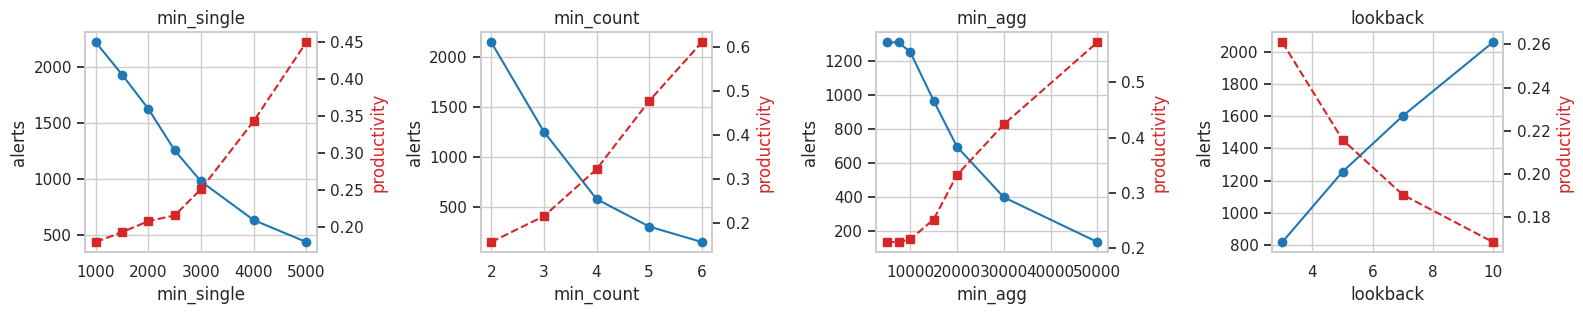

In [3]:
sens = {"min_single": [1000, 1500, 2000, 2500, 3000, 4000, 5000], "min_count": [2, 3, 4, 5, 6],
        "min_agg": [5000, 7500, 10000, 15000, 20000, 30000, 50000], "lookback": [3, 5, 7, 10]}
rows = []
for p, vals in sens.items():
    for v in vals:
        a = run_alerts({p: v}); rows.append(dict(param=p, value=v, alerts=len(a), STR=int(a.str_filed.sum()), productivity=a.str_filed.mean()))
sens_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.3))
for ax, (p, g) in zip(axes, sens_df.groupby("param", sort=False)):
    ax.plot(g.value, g.alerts, "o-", color="tab:blue"); ax.set(title=p, xlabel=p, ylabel="alerts")
    ax2 = ax.twinx(); ax2.plot(g.value, g.productivity, "s--", color="tab:red"); ax2.set_ylabel("productivity", color="tab:red"); ax2.grid(False)
plt.tight_layout(); plt.show()

Direction of effect (book §"Combining parameters"): *raising* `min_single`, `min_count`, `min_agg` → fewer alerts; *lengthening* `lookback` → more alerts. Productivity rises as alerts fall — **but that is not an improvement per se**: fewer alerts also means potentially missed cases. Step 7 quantifies that.

## 3 · Steps 2 & 5 — General statistics and the alert funnel
Always separate *alerts* from *productive alerts* (STR filed). Book metrics: **FPR I** (discarded at alert analysis), **FPR II** (discarded after investigation), **TPR I** (investigated), **TPR II** (filed for reporting).

In [4]:
g = prod.groupby("segment").agg(alerts=("alert_id", "size"), customers_alerted=("customer_id", "nunique"),
                                 investigated=("investigated", "sum"), STR=("str_filed", "sum"))
g["customers"] = kyc.groupby("segment").size()
g["FPR_I"] = (g.alerts - g.investigated) / g.alerts
g["FPR_II"] = (g.investigated - g.STR) / g.alerts
g["TPR_I"] = g.investigated / g.alerts
g["TPR_II (productivity)"] = g.STR / g.alerts
ci = np.array([ak.wilson_ci(k, m) for k, m in zip(g.STR, g.alerts)])
g["CI low"], g["CI high"] = ci[:, 0], ci[:, 1]
g["share of all alerts"] = g.alerts / g.alerts.sum()
g.sort_values("alerts", ascending=False).drop(columns=["customers_alerted"])

,alerts,investigated,STR,customers,FPR_I,FPR_II,TPR_I,TPR_II (productivity),CI low,CI high,share of all alerts
segment,,,,,,,,,,,
cash_intensive,850,377,106,244,0.556,0.319,0.444,0.125,0.104,0.149,0.677
small_business,265,162,78,469,0.389,0.317,0.611,0.294,0.243,0.352,0.211
retail_salaried,68,64,51,1927,0.059,0.191,0.941,0.750,0.636,0.838,0.054
corporate,44,27,15,177,0.386,0.273,0.614,0.341,0.219,0.489,0.035
retail_self_employed,28,24,21,683,0.143,0.107,0.857,0.750,0.566,0.873,0.022


Is productivity the same across segments?  chi2=217.2, dof=4, p=7.54e-46, Cramer's V=0.42  -> strongly heterogeneous


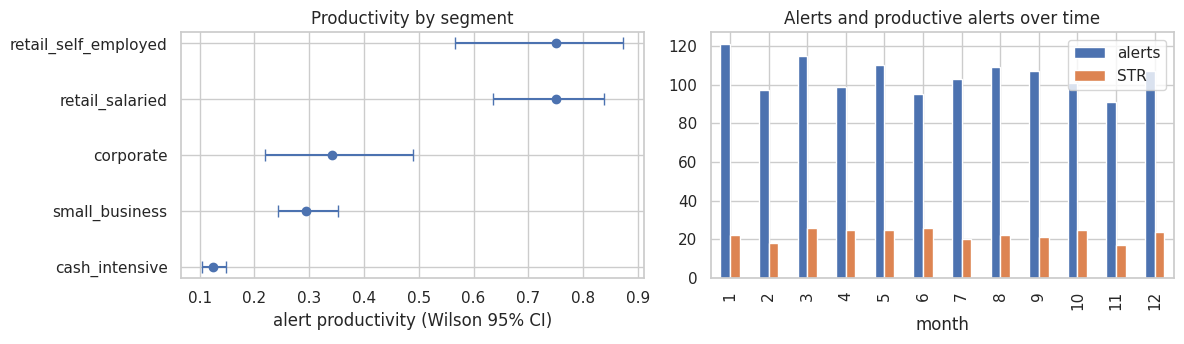

In [5]:
chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(prod.segment, prod.str_filed))
V = np.sqrt(chi2 / (len(prod) * 1))
print(f"Is productivity the same across segments?  chi2={chi2:.1f}, dof={dof}, p={p:.2e}, Cramer's V={V:.2f}  -> strongly heterogeneous")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
gg = g.sort_values("TPR_II (productivity)")
ax[0].errorbar(gg["TPR_II (productivity)"], range(len(gg)), xerr=[gg["TPR_II (productivity)"] - gg["CI low"], gg["CI high"] - gg["TPR_II (productivity)"]], fmt="o", capsize=4)
ax[0].set_yticks(range(len(gg))); ax[0].set_yticklabels(gg.index); ax[0].set(xlabel="alert productivity (Wilson 95% CI)", title="Productivity by segment")
m = prod.assign(month=prod.alert_date.dt.month).groupby("month").agg(alerts=("alert_id", "size"), STR=("str_filed", "sum"))
m.plot.bar(ax=ax[1]); ax[1].set(title="Alerts and productive alerts over time", xlabel="month")
plt.tight_layout(); plt.show()

**Reading:** one heterogeneous segment (cash-intensive businesses) generates most alerts at low productivity, while retail segments generate few alerts but nearly all are productive. **One global threshold cannot fit both** — this is the statistical case for per-segment thresholds (§8).

## 4 · Step 6 — Statistical analysis of each tunable threshold variable
The variable behind `min_agg`: the 5-day aggregate of qualifying cash deposits, per customer-day (windows with at least one qualifying deposit). Zeros are treated separately: most customer-days have no qualifying deposit.

In [6]:
wc, wa = ak.cash_window_matrices(txn, n, min_single=PROD["min_single"], lookback=PROD["lookback"])
mask = wc >= 1
vals = wa[mask]
segv = np.broadcast_to(seg_of.values[:, None], wa.shape)[mask]
print(f"customer-days with no qualifying deposit (structural zeros, excluded): {(wc == 0).mean():.1%}")

desc = pd.Series({"mean": vals.mean(), "std": vals.std(), "skewness": stats.skew(vals), "kurtosis": stats.kurtosis(vals),
                  "min": vals.min(), "max": vals.max(), "production threshold A": PROD["min_agg"],
                  "percentile of A": stats.percentileofscore(vals, PROD["min_agg"])})
print(desc.to_string(float_format=lambda x: f"{x:,.1f}"))
pct = pd.DataFrame({"percentile": [50, 75, 90, 95, 99, 99.5, 99.9]})
pct["aggregate USD"] = np.percentile(vals, pct.percentile)
pct

customer-days with no qualifying deposit (structural zeros, excluded): 92.7%
mean                       7,851.0
std                        8,253.5
skewness                       4.7
kurtosis                      46.0
min                        2,500.2
max                      207,817.8
production threshold A    10,000.0
percentile of A               78.9


,percentile,aggregate USD
0,50.000,"5,025.910"
1,75.000,"8,864.370"
2,90.000,"15,945.060"
3,95.000,"22,632.848"
4,99.000,"42,801.720"
5,99.500,"51,130.450"
6,99.900,"78,793.740"


Book, on the *mean + 2 SD* shortcut: valid only for roughly normal data. Here skewness and kurtosis are large, so 2 SD above the mean lands at a different percentile than 97.7 % — and the mean and SD are themselves inflated by the tail they are meant to cut off:

mean + 2 SD = 24,358 USD  ->  percentile 95.7  (a normal distribution would give 97.7)
median-based robust rule (median + 3.5 MAD) = 15,789 USD


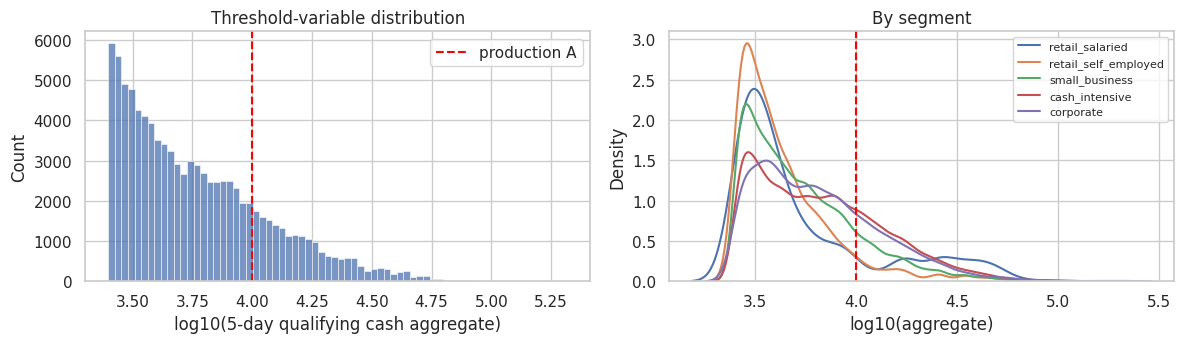

In [7]:
thr_2sd = vals.mean() + 2 * vals.std()
print(f"mean + 2 SD = {thr_2sd:,.0f} USD  ->  percentile {stats.percentileofscore(vals, thr_2sd):.1f}  (a normal distribution would give 97.7)")
print(f"median-based robust rule (median + 3.5 MAD) = {np.median(vals) + 3.5 * stats.median_abs_deviation(vals, scale='normal'):,.0f} USD")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
sns.histplot(np.log10(vals), bins=70, ax=ax[0]); ax[0].axvline(np.log10(PROD["min_agg"]), color="red", ls="--", label="production A")
ax[0].set(xlabel="log10(5-day qualifying cash aggregate)", title="Threshold-variable distribution"); ax[0].legend()
for s in ak.SEGMENTS:
    sns.kdeplot(np.log10(vals[segv == s]), ax=ax[1], label=s)
ax[1].axvline(np.log10(PROD["min_agg"]), color="red", ls="--"); ax[1].set(xlabel="log10(aggregate)", title="By segment"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Multiple peaks?** The book says a single peak is normal; several peaks hint at heterogeneous groups that should be split. Test formally with Gaussian mixtures on the customer-level maximum (lower BIC = better):

In [8]:
cust_max = pd.Series(wa.max(axis=1))[(wa.max(axis=1) > 0)]
lx = np.log10(cust_max.values).reshape(-1, 1)
bic = {k: GaussianMixture(k, random_state=0, n_init=3).fit(lx).bic(lx) for k in range(1, 5)}
print("BIC by number of mixture components (all customers):", {k: round(v) for k, v in bic.items()}, "-> best k =", min(bic, key=bic.get))
bys = pd.DataFrame({s: {k: GaussianMixture(k, random_state=0, n_init=3).fit(np.log10(cust_max[seg_of.reindex(cust_max.index) == s].values).reshape(-1, 1)).bic(np.log10(cust_max[seg_of.reindex(cust_max.index) == s].values).reshape(-1, 1)) for k in (1, 2, 3)} for s in ak.SEGMENTS}).round(0)
bys.loc["best k"] = bys.idxmin()
bys

BIC by number of mixture components (all customers): {1: 1838, 2: 1354, 3: 1374, 4: 1306} -> best k = 4


,retail_salaried,retail_self_employed,small_business,cash_intensive,corporate
1,90.000,13.000,267.000,69.000,74.000
2,-264.000,-58.000,285.000,87.000,91.000
3,-341.000,-83.000,281.000,99.000,92.000
best k,3.000,3.000,1.000,1.000,1.000


Pooled across segments the distribution is multi-modal (a mixture of segments!). The three business segments are single-peaked (homogeneous), whereas the retail segments still show extra peaks: a small group with far higher cash aggregates than salaried peers (in this lab, the planted launderers) — exactly the kind of sub-group step 6 tells you to investigate. Now connect the distribution to outcomes: **productivity by band of the threshold variable** (the book's percentile ranking table with productive alerts).

In [9]:
bands = [10_000, 15_000, 20_000, 30_000, 50_000, np.inf]
prod["band"] = pd.cut(prod.agg_amt, bands, right=False)
bt = prod.groupby("band", observed=True).agg(alerts=("alert_id", "size"), STR=("str_filed", "sum"))
bt["productivity"] = bt.STR / bt.alerts
ci = np.array([ak.wilson_ci(k, m) for k, m in zip(bt.STR, bt.alerts)]); bt["CI low"], bt["CI high"] = ci[:, 0], ci[:, 1]
bt["band starts at percentile"] = [stats.percentileofscore(vals, b) if np.isfinite(b) else np.nan for b in [x.left for x in bt.index]]
bt

,alerts,STR,productivity,CI low,CI high,band starts at percentile
band,,,,,,
"[10000.0, 15000.0)",428,43,0.100,0.075,0.133,78.946
"[15000.0, 20000.0)",309,27,0.087,0.061,0.124,88.846
"[20000.0, 30000.0)",351,132,0.376,0.327,0.428,93.701
"[30000.0, 50000.0)",149,65,0.436,0.359,0.516,97.384
"[50000.0, inf)",18,4,0.222,0.090,0.452,99.449


Productivity is flat at ≈ 9–10 % up to $20k and then jumps to ≈ 38–44 % — the signature of structured deposits (7.5k–9.9k × 3+ ⇒ aggregates ≥ $20k), while cash-intensive businesses generate the bulk of the 10–20k alerts. The top band has fewer than 20 alerts, so its interval is very wide (thin tails are noisy). With 100–400 alerts per band we cannot pin a threshold to the nearest $1,000: report **ranges**, not point estimates (see notebook 05).

## 5 · Step 7 — Above-the-line and below-the-line analysis
* **Above-the-line (ATL):** *raise* a threshold; alerts disappear. Historic dispositions tell you how many **productive** alerts you would have lost.
* **Below-the-line (BTL):** *lower* a threshold; new alerts appear that were **never investigated** — you do not know their productivity. This is the only way to find false negatives; it needs sampling and mock investigation (step 9).

In [10]:
atl = pd.DataFrame({A: kpis(run_alerts({"min_agg": A})) for A in [7500, 10_000, 12_500, 15_000, 20_000, 25_000, 30_000, 40_000, 50_000]}).T
atl.index.name = "min_agg (A)"
atl["STR retained vs production"] = atl.STR_alerts / kpis(prod).STR_alerts
atl

,alerts,STR_alerts,productivity,launderers_alerted,launderers_missed,cost,STR retained vs production
min_agg (A),,,,,,,
7500,"1,312.000",277.000,0.211,74.000,49.000,"291,575.000",1.022
10000,"1,255.000",271.000,0.216,73.000,50.000,"294,280.000",1.000
12500,"1,110.000",251.000,0.226,70.000,53.000,"303,655.000",0.926
15000,969.000,244.000,0.252,68.000,55.000,"307,625.000",0.900
20000,698.000,232.000,0.332,62.000,61.000,"325,970.000",0.856
25000,526.000,206.000,0.392,58.000,65.000,"339,400.000",0.760
30000,401.000,170.000,0.424,54.000,69.000,"355,395.000",0.627
40000,255.000,131.000,0.514,52.000,71.000,"360,580.000",0.483
50000,138.000,79.000,0.572,46.000,77.000,"387,655.000",0.292


In [11]:
btl = pd.DataFrame({m: kpis(run_alerts({"min_single": m})) for m in [500, 1000, 1500, 2000, 2500, 3000, 4000, 5000]}).T
btl.index.name = "min_single (m)"
p0 = kpis(prod)
btl["extra alerts vs prod"] = btl.alerts - p0.alerts
btl["extra STR vs prod"] = btl.STR_alerts - p0.STR_alerts
btl["marginal productivity"] = (btl["extra STR vs prod"] / btl["extra alerts vs prod"]).where(btl["extra alerts vs prod"] > 0)
btl

,alerts,STR_alerts,productivity,launderers_alerted,launderers_missed,cost,extra alerts vs prod,extra STR vs prod,marginal productivity
min_single (m),,,,,,,,,
500,"2,443.000",416.000,0.170,98.000,25.000,"216,215.000","1,188.000",145.000,0.122
1000,"2,215.000",399.000,0.180,95.000,28.000,"221,720.000",960.000,128.000,0.133
1500,"1,928.000",373.000,0.193,90.000,33.000,"234,975.000",673.000,102.000,0.152
2000,"1,623.000",338.000,0.208,89.000,34.000,"227,825.000",368.000,67.000,0.182
2500,"1,255.000",271.000,0.216,73.000,50.000,"294,280.000",0.000,0.000,NaN
3000,979.000,246.000,0.251,68.000,55.000,"307,985.000",-276.000,-25.000,NaN
4000,636.000,218.000,0.343,62.000,61.000,"323,810.000",-619.000,-53.000,NaN
5000,441.000,198.000,0.449,56.000,67.000,"345,935.000",-814.000,-73.000,NaN


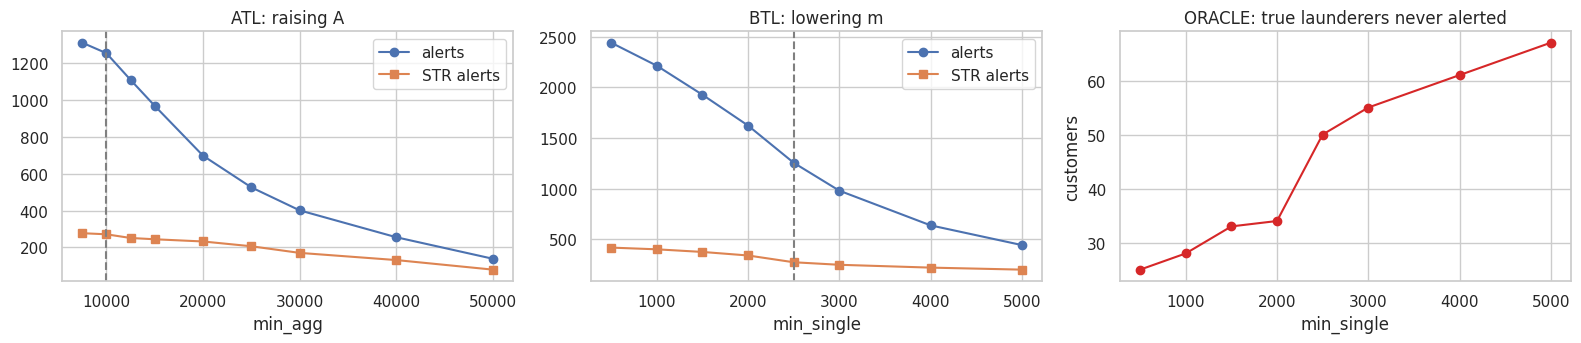

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
ax[0].plot(atl.index, atl.alerts, "o-", label="alerts"); ax[0].plot(atl.index, atl.STR_alerts, "s-", label="STR alerts"); ax[0].axvline(PROD["min_agg"], ls="--", c="grey")
ax[0].set(title="ATL: raising A", xlabel="min_agg"); ax[0].legend()
ax[1].plot(btl.index, btl.alerts, "o-", label="alerts"); ax[1].plot(btl.index, btl.STR_alerts, "s-", label="STR alerts"); ax[1].axvline(PROD["min_single"], ls="--", c="grey")
ax[1].set(title="BTL: lowering m", xlabel="min_single"); ax[1].legend()
ax[2].plot(btl.index, btl.launderers_missed, "o-", color="tab:red"); ax[2].set(title="ORACLE: true launderers never alerted", xlabel="min_single", ylabel="customers")
plt.tight_layout(); plt.show()

Lowering `min_single` surfaces launderers who deliberately stay *below the single-transaction floor* ("low-and-slow"), at a price in workload. A real bank cannot draw the red line on the right — it must estimate it by **sampling below-the-line alerts** (§7).

### Scatterplots and parameter interactions
Two threshold variables together (`agg_amt` and `n_trx`) show interactions the one-at-a-time view hides. Use a permissive run and mark the productive alerts.

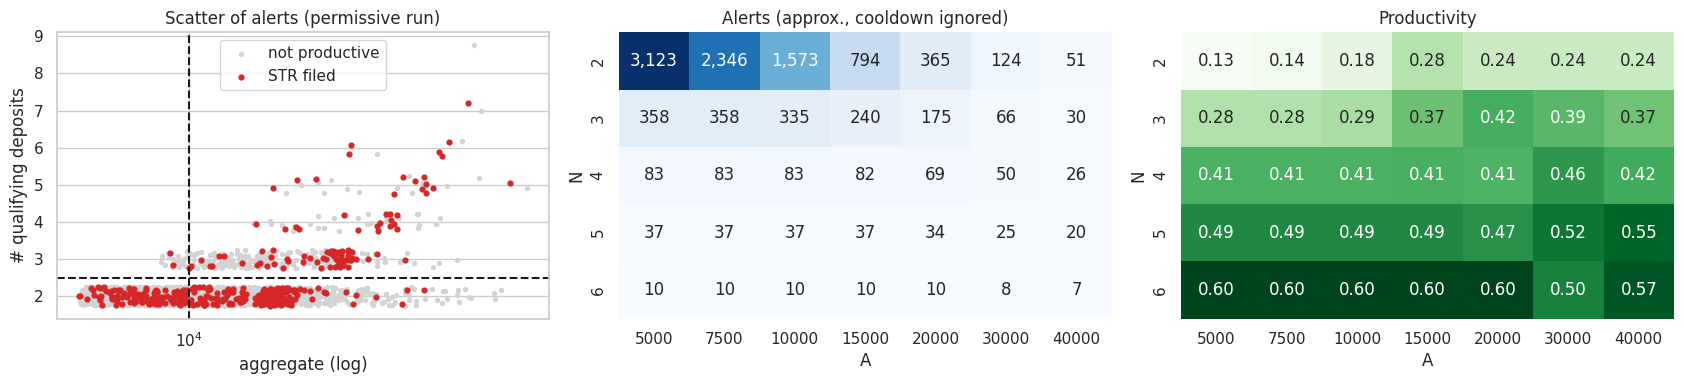

In [13]:
base = ak.simulate_dispositions(ak.run_scenario(txn, n, min_single=2500, min_count=2, min_agg=5000), truth)
rng = np.random.default_rng(0)
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
jit = base.n_trx + rng.uniform(-0.25, 0.25, len(base))
ax[0].scatter(base.agg_amt[base.str_filed == 0], jit[base.str_filed == 0], s=8, c="lightgrey", label="not productive")
ax[0].scatter(base.agg_amt[base.str_filed == 1], jit[base.str_filed == 1], s=12, c="tab:red", label="STR filed")
ax[0].set_xscale("log"); ax[0].axvline(PROD["min_agg"], ls="--", c="k"); ax[0].axhline(PROD["min_count"] - .5, ls="--", c="k")
ax[0].set(xlabel="aggregate (log)", ylabel="# qualifying deposits", title="Scatter of alerts (permissive run)"); ax[0].legend()

As = [5000, 7500, 10_000, 15_000, 20_000, 30_000, 40_000]; Ns = [2, 3, 4, 5, 6]
cnt = pd.DataFrame([[((base.agg_amt >= A) & (base.n_trx >= N)).sum() for A in As] for N in Ns], index=Ns, columns=As)
str_ = pd.DataFrame([[base.str_filed[(base.agg_amt >= A) & (base.n_trx >= N)].sum() for A in As] for N in Ns], index=Ns, columns=As)
sns.heatmap(cnt, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax[1]); ax[1].set(title="Alerts (approx., cooldown ignored)", xlabel="A", ylabel="N")
sns.heatmap((str_ / cnt.replace(0, np.nan)), annot=True, fmt=".2f", cmap="Greens", cbar=False, ax=ax[2]); ax[2].set(title="Productivity", xlabel="A", ylabel="N")
plt.tight_layout(); plt.show()

### Binary search for a threshold hitting a capacity target
Alerts fall (almost) monotonically as a threshold rises, so bisection finds the value that yields, say, ≈ 700 alerts — a way to trade productivity against analyst capacity. Note it is a *step function*, hence a tolerance.

In [14]:
def bisect_threshold(param, lo, hi, target, tol=15, max_iter=25):
    trace = []
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        k = len(ak.run_scenario(txn, n, **{**PROD, param: mid}))
        trace.append((round(mid), k))
        if abs(k - target) <= tol: break
        lo, hi = (mid, hi) if k > target else (lo, mid)         # too many alerts -> raise threshold
    return mid, k, trace

A_star, k_star, trace = bisect_threshold("min_agg", 7500, 100_000, target=700)
print(f"A* = {A_star:,.0f} USD gives {k_star} alerts;  search trace (A, alerts): {trace}")
kpis(run_alerts({"min_agg": A_star}))

A* = 19,785 USD gives 705 alerts;  search trace (A, alerts): [(53750, 86), (30625, 397), (19062, 736), (24844, 530), (21953, 626), (20508, 675), (19785, 705)]


alerts                   705.000
STR_alerts               231.000
productivity               0.328
launderers_alerted        63.000
launderers_missed         60.000
cost                 321,330.000
dtype: float64

## 6 · Step 8 — What-if analysis (back-tests)
Run candidate parameter sets against the same history and compare with production. Alerts that already existed keep their known disposition; **new** alerts need mock investigation (here: the simulator). Compare on *workload*, *productive alerts retained* and *exposure*:

In [15]:
seg_cfg_eff = {   # "efficiency-first": strictest set, maximises productivity
    "retail_salaried":      dict(min_single=1000, min_count=3, min_agg=5000),
    "retail_self_employed": dict(min_single=1500, min_count=3, min_agg=7500),
    "small_business":       dict(min_single=2500, min_count=4, min_agg=15000),
    "cash_intensive":       dict(min_single=3000, min_count=5, min_agg=30000),
    "corporate":            dict(min_single=5000, min_count=3, min_agg=20000),
}
seg_cfg = {       # "balanced": lower single-deposit floor everywhere (below-the-line risk), stricter count/aggregate where noise is high
    "retail_salaried":      dict(min_single=1000, min_count=3, min_agg=5000),
    "retail_self_employed": dict(min_single=1000, min_count=3, min_agg=5000),
    "small_business":       dict(min_single=1500, min_count=4, min_agg=12000),
    "cash_intensive":       dict(min_single=1500, min_count=5, min_agg=20000),
    "corporate":            dict(min_single=2500, min_count=3, min_agg=15000),
}
cands = {
    "Production (m=2.5k, N=3, A=10k)":   prod,
    "Raise A to 20k":                    run_alerts({"min_agg": 20_000}),
    "Raise N to 4":                      run_alerts({"min_count": 4}),
    "Lower m to 1.5k":                   run_alerts({"min_single": 1500}),
    "Per-segment: efficiency-first":     run_alerts(segment_params=seg_cfg_eff),
    "Per-segment: balanced":             run_alerts(segment_params=seg_cfg),
}
wi = pd.DataFrame({k: kpis(v) for k, v in cands.items()}).T
wi["Δ alerts"] = wi.alerts - wi.alerts.iloc[0]
wi["Δ STR alerts"] = wi.STR_alerts - wi.STR_alerts.iloc[0]
wi

,alerts,STR_alerts,productivity,launderers_alerted,launderers_missed,cost,Δ alerts,Δ STR alerts
"Production (m=2.5k, N=3, A=10k)","1,255.000",271.000,0.216,73.000,50.000,"294,280.000",0.000,0.000
Raise A to 20k,698.000,232.000,0.332,62.000,61.000,"325,970.000",-557.000,-39.000
Raise N to 4,583.000,188.000,0.322,62.000,61.000,"322,775.000",-672.000,-83.000
Lower m to 1.5k,"1,928.000",373.000,0.193,90.000,33.000,"234,975.000",673.000,102.000
Per-segment: efficiency-first,362.000,218.000,0.602,61.000,62.000,"316,480.000",-893.000,-53.000
Per-segment: balanced,725.000,270.000,0.372,79.000,44.000,"240,475.000",-530.000,-1.000


Cost view (*assumptions*: $45 per unproductive alert, $5,000 per missed launderer). The ranking depends on the FN cost — check how sensitive the conclusion is before defending it to the regulator:

In [16]:
rows = {}
for c_fn in [250, 500, 1000, 2500, 5000, 10_000]:
    rows[c_fn] = {k: (len(v) - v.str_filed.sum()) * C_FP + kpis(v).launderers_missed * c_fn for k, v in cands.items()}
cost = pd.DataFrame(rows); cost.columns.name = "cost of a missed launderer (USD)"
cost.style.format("{:,.0f}").highlight_min(axis=0, color="#c7f0c7")

cost of a missed launderer (USD),250,500,1000,2500,5000,10000
"Production (m=2.5k, N=3, A=10k)","56,780","69,280","94,280","169,280","294,280","544,280"
Raise A to 20k,"36,220","51,470","81,970","173,470","325,970","630,970"
Raise N to 4,"33,025","48,275","78,775","170,275","322,775","627,775"
Lower m to 1.5k,"78,225","86,475","102,975","152,475","234,975","399,975"
Per-segment: efficiency-first,"21,980","37,480","68,480","161,480","316,480","626,480"
Per-segment: balanced,"31,475","42,475","64,475","130,475","240,475","460,475"


## 7 · Step 9 — Mock investigations on new (below-the-line) alerts
Candidate "Lower m to 1.5k" creates alerts on customers who were **never alerted** before. Before adopting it, sample those alerts, have investigators work them, and estimate their productivity **with a confidence interval**. *Practical Statistics*: sample size drives the interval width (notebook 01 §5.5).

In [17]:
cand = cands["Lower m to 1.5k"]
new_c = set(cand.customer_id) - set(prod.customer_id)
new_alerts = cand[cand.customer_id.isin(new_c)].sort_values("alert_day").groupby("customer_id").head(1).reset_index(drop=True)
print(f"newly alerted customers: {len(new_alerts)}   (true productivity among them = {new_alerts.str_filed.mean():.1%} <- unknowable in real life)")

def stratified_sample(df, n_total, seed):
    r = np.random.default_rng(seed); parts = []
    for s, d in df.groupby("segment"):
        k = min(len(d), max(1, round(n_total * len(d) / len(df))))
        parts.append(d.iloc[r.choice(len(d), k, replace=False)])
    return pd.concat(parts)

for n_s in (30, 60, 120):
    smp = stratified_sample(new_alerts, n_s, 0)
    lo, hi = ak.wilson_ci(smp.str_filed.sum(), len(smp))
    print(f"mock investigation of {len(smp):3d} alerts -> productivity {smp.str_filed.mean():5.1%}   95% CI ({lo:.1%}, {hi:.1%})")

cover = np.mean([ak.wilson_ci((s := stratified_sample(new_alerts, 60, seed)).str_filed.sum(), len(s))[0] <= new_alerts.str_filed.mean() <= ak.wilson_ci(s.str_filed.sum(), len(s))[1] for seed in range(500)])
print(f"coverage of the Wilson 95% CI over 500 repeated mock investigations (n=60): {cover:.1%}  (>95%: we sample about half of a small finite population, so the plain Wilson interval is conservative - a finite-population correction would tighten it)")

newly alerted customers: 121   (true productivity among them = 13.2% <- unknowable in real life)
mock investigation of  30 alerts -> productivity 13.3%   95% CI (5.3%, 29.7%)
mock investigation of  59 alerts -> productivity  6.8%   95% CI (2.7%, 16.2%)
mock investigation of 120 alerts -> productivity 13.3%   95% CI (8.4%, 20.6%)


coverage of the Wilson 95% CI over 500 repeated mock investigations (n=60): 100.0%  (>95%: we sample about half of a small finite population, so the plain Wilson interval is conservative - a finite-population correction would tighten it)


## 8 · Step 10 — Customer (re)segmentation
Step 5 showed productivity differs sharply by segment. Before per-segment thresholds, check which parameter changes help **inside each segment** (table below), and compare two ways of setting per-segment thresholds:

1. **Statistical:** A = a high percentile of each segment's own distribution (mechanical, defensible, but see the caveat);
2. **Analyst-informed:** parameters chosen from the segment-level ATL/BTL table.

In [18]:
rows = []
for name, p in {"m=2.5k,N=3": {}, "m=1k,N=3": {"min_single": 1000}, "m=2.5k,N=4": {"min_count": 4}, "m=2.5k,N=5": {"min_count": 5}, "m=2.5k,A=30k": {"min_agg": 30_000}}.items():
    a = run_alerts(p)
    r = a.groupby("segment").agg(alerts=("alert_id", "size"), STR=("str_filed", "sum")); r["productivity"] = r.STR / r.alerts; r["set"] = name
    rows.append(r.reset_index())
seg_tab = pd.concat(rows).pivot(index="segment", columns="set", values="productivity")
seg_cnt = pd.concat(rows).pivot(index="segment", columns="set", values="alerts")
print("Alerts"); display(seg_cnt.astype(int)); print("Productivity"); display(seg_tab.style.format("{:.0%}").background_gradient(cmap="Greens", axis=None))

Alerts


set,"m=1k,N=3","m=2.5k,A=30k","m=2.5k,N=3","m=2.5k,N=4","m=2.5k,N=5"
segment,,,,,
cash_intensive,1424,210,850,384,173
corporate,77,25,44,22,16
retail_salaried,90,54,68,54,44
retail_self_employed,57,20,28,20,17
small_business,567,92,265,103,58


Productivity


set,"m=1k,N=3","m=2.5k,A=30k","m=2.5k,N=3","m=2.5k,N=4","m=2.5k,N=5"
segment,,,,,
cash_intensive,11%,21%,12%,16%,25%
corporate,29%,48%,34%,50%,81%
retail_salaried,77%,80%,75%,80%,80%
retail_self_employed,60%,85%,75%,85%,88%
small_business,20%,59%,29%,55%,71%


In [19]:
dfv = pd.DataFrame({"v": vals, "s": segv})
q = dfv.groupby("s").v.quantile(0.97)
stat_cfg = {s: dict(min_agg=float(max(q[s], 7500))) for s in q.index}
print("statistical thresholds (97th percentile of each segment's own distribution):", {s: round(v['min_agg']) for s, v in stat_cfg.items()})
cmp = pd.DataFrame({"Production": kpis(prod), "Statistical (p97 per segment)": kpis(run_alerts(segment_params=stat_cfg)),
                    "Analyst-informed per segment (balanced)": kpis(cands["Per-segment: balanced"])}).T
cmp

statistical thresholds (97th percentile of each segment's own distribution): {'cash_intensive': 30985, 'corporate': 28694, 'retail_salaried': 43913, 'retail_self_employed': 17695, 'small_business': 22850}


,alerts,STR_alerts,productivity,launderers_alerted,launderers_missed,cost
Production,"1,255.000",271.000,0.216,73.000,50.000,"294,280.000"
Statistical (p97 per segment),419.000,171.000,0.408,55.000,68.000,"351,160.000"
Analyst-informed per segment (balanced),725.000,270.000,0.372,79.000,44.000,"240,475.000"


**Why does the mechanical percentile rule do worse?** (Look at launderers alerted, not only productivity.) The segment distributions *contain the launderers themselves*. A percentile of a contaminated distribution inherits the contamination — most visibly in `retail_salaried`, where the few launderers inflate the upper percentiles so much that the rule stops flagging them. This is the **circularity** problem again (notebook 05). Analyst-informed thresholds carry domain knowledge ("a salaried retail customer should almost never deposit ≥ $1,000 in cash three times in five days") that the data alone cannot supply.

⚠ **Honesty check.** I tried a handful of per-segment sets while looking at oracle results before settling on the *balanced* one. That is a small "garden of forking paths": the improvement shown is optimistic. A real bank sees only STRs, not the oracle — notebook 05 measures how badly this can mislead.

## 9 · Step 11 — Report write-up
The book's scenario review report: *current production vs suggested*, with parameter percentiles. Generate it from the analysis so that every number is traceable:

In [20]:
rep_rows = []
for s in ak.SEGMENTS:
    v = vals[segv == s]
    rep_rows.append(dict(segment=s, **{f"prod {k}": PROD[k] for k in ("min_single", "min_count", "min_agg")},
                         **{f"proposed {k}": seg_cfg[s][k] for k in ("min_single", "min_count", "min_agg")},
                         **{"prod A percentile (in-segment)": stats.percentileofscore(v, PROD["min_agg"]),
                            "proposed A percentile (in-segment)": stats.percentileofscore(v, seg_cfg[s]["min_agg"])}))
report_params = pd.DataFrame(rep_rows).set_index("segment"); report_params

,prod min_single,prod min_count,prod min_agg,proposed min_single,proposed min_count,proposed min_agg,prod A percentile (in-segment),proposed A percentile (in-segment)
segment,,,,,,,,
retail_salaried,2500,3,10000,1000,3,5000,82.289,66.436
retail_self_employed,2500,3,10000,1000,3,5000,92.899,71.990
small_business,2500,3,10000,1500,4,12000,85.123,89.170
cash_intensive,2500,3,10000,1500,5,20000,72.586,91.880
corporate,2500,3,10000,2500,3,15000,75.465,87.343


In [21]:
summary = pd.DataFrame({"Current production": kpis(prod), "Suggested (per-segment, balanced)": kpis(cands["Per-segment: balanced"])})
summary.loc["STR-filed alerts retained"] = [1.0, summary.loc["STR_alerts", "Suggested (per-segment, balanced)"] / summary.loc["STR_alerts", "Current production"]]
summary.loc["alert reduction"] = [0.0, 1 - summary.loc["alerts", "Suggested (per-segment, balanced)"] / summary.loc["alerts", "Current production"]]
summary

,Current production,"Suggested (per-segment, balanced)"
alerts,"1,255.000",725.000
STR_alerts,271.000,270.000
productivity,0.216,0.372
launderers_alerted,73.000,79.000
launderers_missed,50.000,44.000
cost,"294,280.000","240,475.000"
STR-filed alerts retained,1.000,0.996
alert reduction,0.000,0.422


### Recommendations section (template — fill with *your* findings)
1. **Findings:** productivity by segment; distribution shape; parameter interactions.
2. **Recommended thresholds:** table above, each with its ATL loss and BTL estimate **with confidence intervals**.
3. **Residual risk:** what the analysis *cannot* see (below-the-line, new typologies) and how it will be monitored (regular under-the-line sampling; the book's *safety-blanket* rules stay on regardless of productivity).
4. **Other issues:** data gaps, missing scenarios, staff training (book §"Scenario review results").
5. **Re-tuning trigger:** e.g. every 6 months or on a PSI/SSI breach (notebook 08).

⚠ **Read this before you trust the numbers:** in the lab, the improvement above is measured with an oracle. In a real bank, "STR retained" is the *only* evidence you have, and it is contaminated by the very thresholds being tuned. **Notebook 05** tests exactly how far that evidence can be trusted.

**Next → `05_threshold_tuning_statistical_critique`**